In [0]:
%%capture
!apt-get install -y -qq software-properties-common python-software-properties module-init-tools
!add-apt-repository -y ppa:fenics-packages/fenics
!apt-get update -qq
!apt install -y --no-install-recommends fenics
!rm -rf *
from fenics import *

# Stabilized Methods (Stokes Equation)

---



### MINI element

Spaces are defined as follow:

1.   Q = FiniteElement('CG', mesh.ufl_cell(), 1)
2.   B = FiniteElement('Bubble', mesh.ufl_cell(), mesh.topology().dim()+1)
3. V = VectorElement(NodalEnrichedElement(Q, B))
4. X = FunctionSpace(mesh, V*Q) 



  

In [0]:
def stokes_MINI(n, u_exact, gN, f):
  mesh=UnitSquareMesh(n, n, "crossed")
  b_m = MeshFunction("size_t", mesh, mesh.geometric_dimension()-1, 0)

  class top_bc(SubDomain):
    def inside(self, x, on_boundary):
      return on_boundary and near(x[1], 1)
  class other_bc(SubDomain):
    def inside(self, x, on_boundary):
      return on_boundary and not near(x[1], 1)
  
  top=top_bc()
  top.mark(b_m, 1)
  other=other_bc()
  other.mark(b_m, 2)

  ds = Measure('ds', domain=mesh, subdomain_data=b_m)

  Q = FiniteElement('CG', mesh.ufl_cell(), 1)
  B = FiniteElement('Bubble', mesh.ufl_cell(), mesh.topology().dim()+1)
  V = VectorElement(NodalEnrichedElement(Q, B))
  X = FunctionSpace(mesh, V*Q)

  u, p = TrialFunctions(X)
  v, q = TestFunctions(X)

  bc =  DirichletBC(X.sub(0), u_exact, b_m, 2)

  a = (inner(grad(u), grad(v))-p*div(v) - q*div(u))*dx
  L = dot(f, v)*dx + dot(gN, v)*ds(1)

  x = Function(X)
  solve (a==L, x, bc)

  u, p = x.split()
  return u, p

## Crouzeix-Raviart element
Spaces are defined as follow:
1. Q = FiniteElement('DG', mesh.ufl_cell(), 0)
3. V = VectorElement('CR', mesh.ufl_cell(), 1)
4. X = FunctionSpace(mesh, V*Q) 

In [0]:
def stokes_CR(n, u_exact, gN, f):
  mesh=UnitSquareMesh(n, n, "crossed")
  b_m = MeshFunction("size_t", mesh, mesh.geometric_dimension()-1, 0)

  class top_bc(SubDomain):
    def inside(self, x, on_boundary):
      return on_boundary and near(x[1], 1)
  class other_bc(SubDomain):
    def inside(self, x, on_boundary):
      return on_boundary and not near(x[1], 1)
  
  top=top_bc()
  top.mark(b_m, 1)
  other=other_bc()
  other.mark(b_m, 2)

  ds = Measure('ds', domain=mesh, subdomain_data=b_m)

  Q = FiniteElement('DG', mesh.ufl_cell(), 0)
  V = VectorElement('CR', mesh.ufl_cell(), 1)
  X = FunctionSpace(mesh, V*Q)

  u, p = TrialFunctions(X)
  v, q = TestFunctions(X)

  bc =  DirichletBC(X.sub(0), u_exact, b_m, 2)

  a = (inner(grad(u), grad(v))-p*div(v) - q*div(u))*dx
  L = dot(f, v)*dx + dot(gN, v)*ds(1)

  x = Function(X)
  solve (a==L, x, bc)

  u, p = x.split()
  return u, p

##SUPG stabilized P1-P1 element

$ a_{stab} = \int \tau_k(\nabla{p} \nabla{q})d\Omega $
                    with $\tau_k= \frac{h^{2}}{2}$

$ L_{stab} = \int f\nabla q d\Omega$

In [0]:
def stokes_SUPG(n, u_exact, gN, f):
  mesh=UnitSquareMesh(n, n, "crossed")
  b_m = MeshFunction("size_t", mesh, mesh.geometric_dimension()-1, 0)

  class top_bc(SubDomain):
    def inside(self, x, on_boundary):
      return on_boundary and near(x[1], 1)
  class other_bc(SubDomain):
    def inside(self, x, on_boundary):
      return on_boundary and not near(x[1], 1)
  
  top=top_bc()
  top.mark(b_m, 1)
  other=other_bc()
  other.mark(b_m, 2)

  ds = Measure('ds', domain=mesh, subdomain_data=b_m)

  Q = FiniteElement('CG', mesh.ufl_cell(), 1)
  V = VectorElement('CG', mesh.ufl_cell(), 1)
  X = FunctionSpace(mesh, V*Q)

  u, p = TrialFunctions(X)
  v, q = TestFunctions(X)

  bc =  DirichletBC(X.sub(0), u_exact, b_m, 2)

  a = (inner(grad(u), grad(v))-p*div(v) - q*div(u))*dx
  L = dot(f, v)*dx + dot(gN, v)*ds(1)

  h = CellDiameter(mesh)
  tau = h**2/2
  a += tau*(inner(grad(p), grad(q)))*dx
  L += tau*dot(f, grad(q))*dx

  x = Function(X)
  solve (a==L, x, bc)

  u, p = x.split()
  return u, p

## Pressure mass matrix

We use


1.   Discontinuous Galerkin $ \mathbb{P}_0$ for the Q Finite Element Space
2.   Term added:
$ \int h^2pq d \Omega$



In [0]:
def stokes_PMat(n, u_exact, gN, f):
  mesh=UnitSquareMesh(n, n, "crossed")
  b_m = MeshFunction("size_t", mesh, mesh.geometric_dimension()-1, 0)

  class top_bc(SubDomain):
    def inside(self, x, on_boundary):
      return on_boundary and near(x[1], 1)
  class other_bc(SubDomain):
    def inside(self, x, on_boundary):
      return on_boundary and not near(x[1], 1)
  
  top=top_bc()
  top.mark(b_m, 1)
  other=other_bc()
  other.mark(b_m, 2)

  ds = Measure('ds', domain=mesh, subdomain_data=b_m)

  Q = FiniteElement('DG', mesh.ufl_cell(), 0)
  V = VectorElement('CG', mesh.ufl_cell(), 1)
  X = FunctionSpace(mesh, V*Q)

  u, p = TrialFunctions(X)
  v, q = TestFunctions(X)

  bc =  DirichletBC(X.sub(0), u_exact, b_m, 2)

  a = (inner(grad(u), grad(v))-p*div(v) - q*div(u))*dx
  L = dot(f, v)*dx + dot(gN, v)*ds(1)

  h = CellDiameter(mesh)
  a += h**2*p*q*dx

  x = Function(X)
  solve (a==L, x, bc)

  u, p = x.split()
  return u, p

## Comparison

In [110]:
u_exact = Expression((
        '-cos(pi*x[0]) * sin(pi*x[1])',
        'sin(pi*x[0]) * cos(pi*x[1])'
                    ), degree=2)
p_exact = Expression(
        '-0.25 * (cos(2*pi*x[0]) + cos(2*pi*x[1]))',
        degree=2)
f = Expression((
        '-2*pi*pi * cos(pi*x[0]) * sin(pi*x[1]) + 0.5*pi * sin(2*pi*x[0])',
        '2*pi*pi * sin(pi*x[0]) * cos(pi*x[1]) + 0.5*pi * sin(2*pi*x[1])'
               ), degree=2)

gN = Expression(('pi * cos(pi*x[0])', '0.25 * (cos(2*pi*x[0]) + cos(2*pi*x[1]))'
                ), degree=2)

n = 10

uh, ph = stokes_MINI(n, u_exact, gN, f)

eL2 = errornorm(p_exact, ph, 'L2')
eH1 = errornorm(u_exact, uh, 'H1')
print('n={} eL2={:.2e} eH1={:.2e}'.format(n, eL2, eH1))


uh, ph = stokes_CR(n, u_exact, gN, f)

eL2 = errornorm(p_exact, ph, 'L2')
eH1 = errornorm(u_exact, uh, 'H1')
print('n={} eL2={:.2e} eH1={:.2e}'.format(n, eL2, eH1))

uh, ph = stokes_SUPG(n, u_exact, gN, f)

eL2 = errornorm(p_exact, ph, 'L2')
eH1 = errornorm(u_exact, uh, 'H1') 
print('n={} eL2={:.2e} eH1={:.2e}'.format(n, eL2, eH1))

uh, ph = stokes_PMat(n, u_exact, gN, f)

eL2 = errornorm(p_exact, ph, 'L2')
eH1 = errornorm(u_exact, uh, 'H1') 
print('n={} eL2={:.2e} eH1={:.2e}'.format(n, eL2, eH1))

n=10 eL2=2.16e-01 eH1=3.03e-01
n=10 eL2=3.88e-01 eH1=4.75e-01
n=10 eL2=2.01e+01 eH1=1.88e+01
n=10 eL2=4.37e-01 eH1=3.32e-01


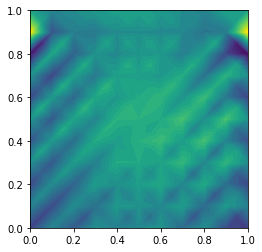

In [111]:
plot(ph)

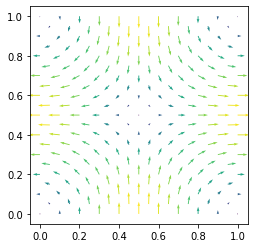

In [112]:
plot(uh)

# Stationary Navier-Stokes Equation

---


We consider the stationary Navier-Stokes problem defined in the unit square domain $\Omega := {[0,1]}^2$
$$
\begin{cases}
  ({\boldsymbol{u}}\cdot\boldsymbol{\nabla})\ \boldsymbol{u}
  -\dfrac{1}{\text{Re}}\boldsymbol{\Delta} \boldsymbol{u} + \boldsymbol{\nabla} p = 0, 
  \qquad&\text{in }\Omega, \\
  \boldsymbol{\nabla} \cdot \boldsymbol{u} = 0, 
  \qquad &\text{in }\Omega, \\
  \boldsymbol{u} = 1\boldsymbol{i} + 0\boldsymbol{j}, \qquad&\text{on }\Gamma^{\text{up}} = \{ 0 \le x \le 1, \, y=1 \}, \\
  \boldsymbol{u} = \boldsymbol{0}, \qquad&\text{on }\partial\Omega \backslash \Gamma^{\text{up}}.
\end{cases}
$$

In [0]:
def stationary_Navier_Stokes(n, p_origin, u_boundary, u_old, f, Re, tol, maxIter):
  def solve_Navier_Stokes(X, p_origin, u_boundary, u_old, f, Re):
    u, p = TrialFunctions(X)
    v, q = TestFunctions(X)

    a = (inner(grad(u), grad(v))/Re - p*div(v) + q*div(u))*dx
    L = dot(f, v)*dx

    # semi-implicit linear method
    if u_old:
      a += dot(grad(u)*u_old, v)*dx
    
    def upper(x, on_boundary):
      return on_boundary and near(x[1], 1)
    
    def other(x, on_boundary):
      return on_boundary and not near(x[1], 1)
    
    def origin(x, on_boundary):
      return on_boundary and near(x[1], 0) and near(x[0], 0)
    
    bc1 = DirichletBC(X.sub(0), u_boundary, upper)
    bc2 = DirichletBC(X.sub(0), Constant((0, 0)), other)
    bc3 = DirichletBC(X.sub(1), Constant(0), origin, 'pointwise')

    bc = [bc1, bc2, bc3]

    x = Function(X)
    solve (a==L, x, bc)
    u, p = x.split()
    return u, p

  mesh = UnitSquareMesh(n, n, 'crossed')
  Q = FiniteElement('CG', mesh.ufl_cell(), 1)
  V = VectorElement('CG', mesh.ufl_cell(), 2)

  X = FunctionSpace(mesh, V*Q)

  u, p = solve_Navier_Stokes(X, p_origin, u_boundary, None, f, Re)

  for i in range(maxIter):
    u_old, p_old = u, p
    u, p = solve_Navier_Stokes(X, p_origin, u_boundary, u_old, f, Re)
    err = errornorm(u_old, u, 'H10')/norm(u_old, 'H10') + errornorm(p_old, p, 'H10')/norm(p_old, 'H10')
    if err<tol:
      break
  
  return u, p, mesh, i, err

In [0]:
u_boundary = Constant((1, 0))
p_origin = Constant(0)
n = 20
f = Constant((0, 0))
Re = Constant(300)
maxIter = 300
tol = 1e-6

u, p, mesh, i, err = stationary_Navier_Stokes(n, p_origin, u_boundary, u_old, f, Re, tol, maxIter)
File('velocity.pvd') << u
File('pressure.pvd') << p

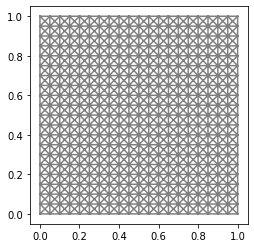

In [115]:
plot(mesh)

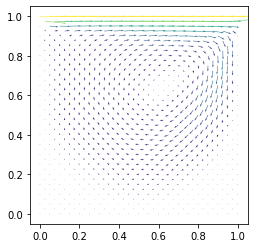

In [116]:
plot(u)

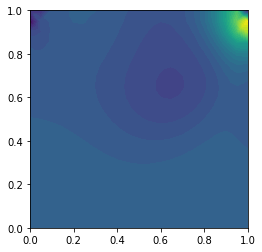

In [117]:
plot(p)